In [77]:
import pandas as pd

df = pd.read_csv('../../../datasets/e_sports.csv')


# Data Oveview

In [78]:
print(f'Shape of the dataset: {df.shape}\n')
print(f'Data types of the dataset: {df.dtypes}\n')
print(f'Name of the features: {df.columns.tolist()}')

Shape of the dataset: (2800, 16)

Data types of the dataset: record_id              int64
player_id              int64
team_name                str
player_role              str
map_played               str
match_type               str
kills                  int64
assists                int64
deaths                 int64
accuracy_percent     float64
reaction_time_ms     float64
fatigue_index        float64
performance_score    float64
win_probability      float64
match_outcome            str
mvp_award                str
dtype: object

Name of the features: ['record_id', 'player_id', 'team_name', 'player_role', 'map_played', 'match_type', 'kills', 'assists', 'deaths', 'accuracy_percent', 'reaction_time_ms', 'fatigue_index', 'performance_score', 'win_probability', 'match_outcome', 'mvp_award']


In [79]:
df.head()

,record_id,player_id,team_name,player_role,map_played,match_type,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
0,1,160,Titan Esports,Flex,Dust Arena,Playoff,18,6,7,40.43,192.28,0.52,50.02,0.83,Win,No
1,2,2,Titan Esports,Support,Neon City,Final,16,7,11,40.50,201.98,0.68,41.45,0.89,Win,No
2,3,468,Team Alpha,Support,Neon City,Semi-Final,14,7,15,36.93,172.50,0.27,35.77,0.81,Win,No
3,4,447,Team Nova,IGL,Desert Storm,Final,12,6,13,53.46,246.83,0.07,43.03,1.00,Win,No
4,5,196,Phantom Squad,Sniper,Skyline,Playoff,13,9,13,44.71,266.94,0.52,39.16,0.85,Win,No


In [80]:
df.tail()

,record_id,player_id,team_name,player_role,map_played,match_type,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability,match_outcome,mvp_award
2795,2796,437,Titan Esports,Sniper,Desert Storm,Qualifier,16,10,14,34.77,210.97,0.89,36.49,0.79,Win,No
2796,2797,109,Red Vortex,Support,Dust Arena,Group Stage,17,9,7,43.17,201.52,0.50,52.59,0.86,Win,No
2797,2798,380,Phantom Squad,Support,Desert Storm,Final,20,9,4,26.73,220.69,0.22,56.16,1.00,Win,No
2798,2799,138,CyberX,Sniper,Skyline,Semi-Final,14,9,10,56.56,174.82,0.35,51.78,1.00,Win,No
2799,2800,396,CyberX,Sniper,Frozen Base,Group Stage,15,5,9,44.80,228.18,0.26,45.80,0.97,Win,No


# Data Quality Check

In [81]:
# Constants features

print(f'{df.nunique()}')

record_id            2800
player_id             497
team_name               6
player_role             5
map_played              5
match_type              5
kills                  26
assists                20
deaths                 22
accuracy_percent     1836
reaction_time_ms     2485
fatigue_index         101
performance_score    2009
win_probability        49
match_outcome           2
mvp_award               2
dtype: int64


In [82]:
# Missing Values

print(f'Missing values:\n{df.isnull().sum()}')

Missing values:
record_id            0
player_id            0
team_name            0
player_role          0
map_played           0
match_type           0
kills                0
assists              0
deaths               0
accuracy_percent     0
reaction_time_ms     0
fatigue_index        0
performance_score    0
win_probability      0
match_outcome        0
mvp_award            0
dtype: int64


In [83]:
#  Duplicated data
print(f'Rows Duplicated: {df.duplicated().sum()}')

Rows Duplicated: 0


In [85]:
# Wrong or Impossible data

# Negative data & scales differents
df.describe()

,record_id,player_id,kills,assists,deaths,accuracy_percent,reaction_time_ms,fatigue_index,performance_score,win_probability
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,247.968214,14.872500,8.027857,10.025000,45.095225,220.129836,0.498875,45.306718,0.916364
std,808.434702,144.472383,3.973451,2.843157,3.178069,8.054907,30.240196,0.291618,10.333504,0.097468
min,1.000000,1.000000,4.000000,0.000000,1.000000,20.460000,118.730000,0.000000,16.580000,0.470000
25%,700.750000,121.000000,12.000000,6.000000,8.000000,39.542500,199.762500,0.240000,38.287500,0.860000
50%,1400.500000,248.000000,15.000000,8.000000,10.000000,44.960000,220.685000,0.500000,44.985000,0.950000
75%,2100.250000,371.000000,18.000000,10.000000,12.000000,50.552500,240.452500,0.760000,52.302500,1.000000
max,2800.000000,500.000000,30.000000,20.000000,22.000000,71.790000,324.110000,1.000000,87.360000,1.000000


In [86]:
# Wrong or Impossible data

# Data Entry
for cat_fet in categorial_features:
    print(f'Differents Values for {cat_fet}: {df[cat_fet].value_counts()}\n')

Differents Values for mvp_award: mvp_award
No     2561
Yes     239
Name: count, dtype: int64

Differents Values for match_outcome: match_outcome
Win     2793
Loss       7
Name: count, dtype: int64

Differents Values for team_name: team_name
Phantom Squad    487
Red Vortex       482
CyberX           473
Team Alpha       467
Titan Esports    453
Team Nova        438
Name: count, dtype: int64

Differents Values for player_role: player_role
Entry Fragger    584
IGL              569
Sniper           558
Flex             552
Support          537
Name: count, dtype: int64

Differents Values for map_played: map_played
Neon City       576
Dust Arena      573
Desert Storm    571
Frozen Base     549
Skyline         531
Name: count, dtype: int64

Differents Values for match_type: match_type
Group Stage    579
Final          570
Semi-Final     562
Playoff        548
Qualifier      541
Name: count, dtype: int64



# Analysis

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# Get the numeric and categorial features

numeric_features = df.select_dtypes(include='number').columns.tolist()
categorial_features = df.select_dtypes(exclude='number').columns.tolist()

print(f'The numeric features list = {numeric_features}, and have {len(numeric_features)} itens')
print(f'The categorial features list = {categorial_features}, and have {len(categorial_features)} itens')

The numeric features list = ['record_id', 'player_id', 'kills', 'assists', 'deaths', 'accuracy_percent', 'reaction_time_ms', 'fatigue_index', 'performance_score', 'win_probability'], and have 10 itens
The categorial features list = ['team_name', 'player_role', 'map_played', 'match_type', 'match_outcome', 'mvp_award'], and have 6 itens


### Distribution and Outliers Analysis

--------------------------------------------------------------------
Feature: record_id


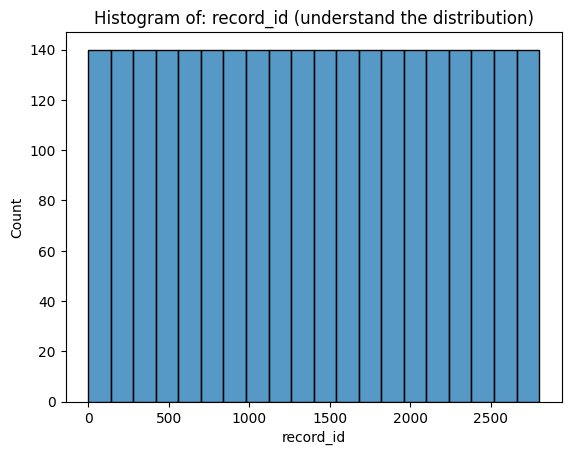

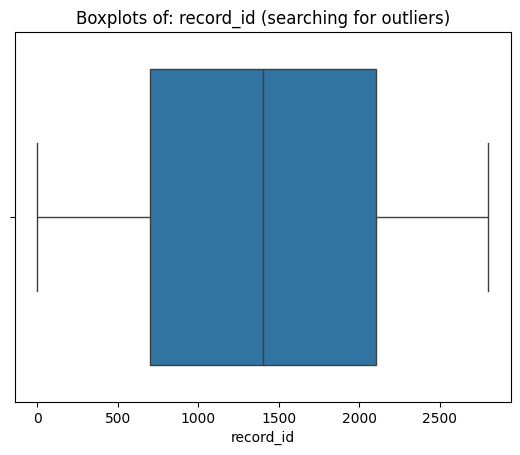





--------------------------------------------------------------------
Feature: player_id


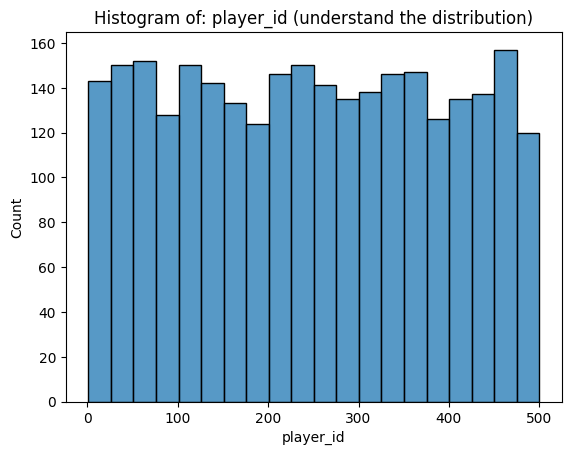

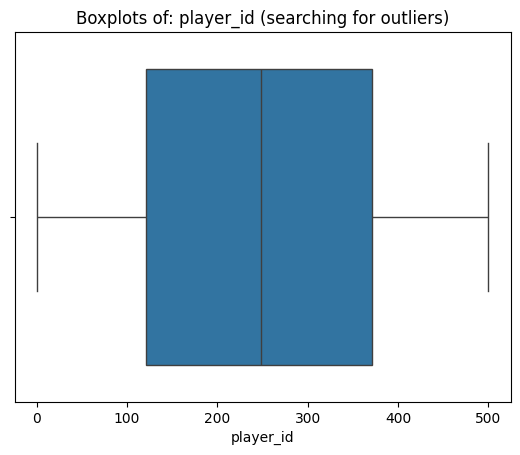





--------------------------------------------------------------------
Feature: kills


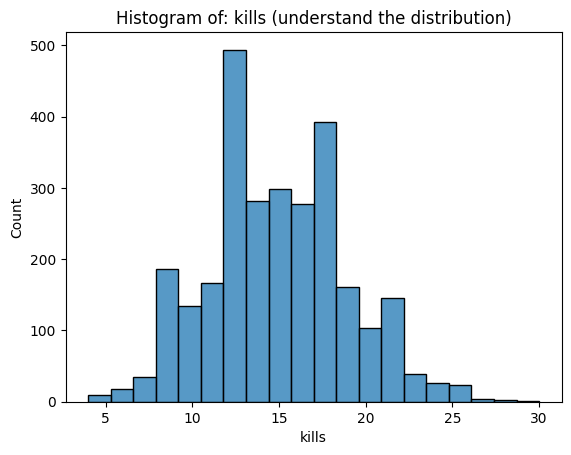

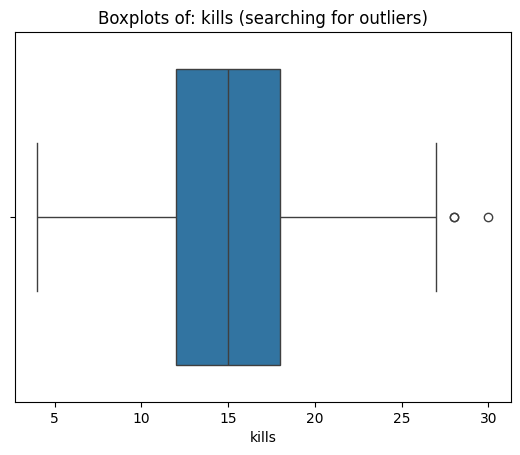





--------------------------------------------------------------------
Feature: assists


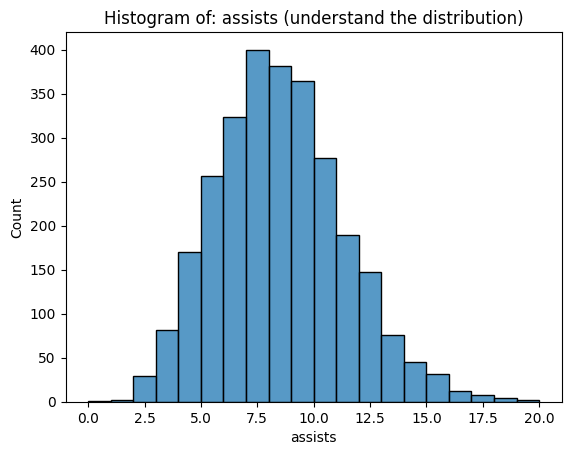

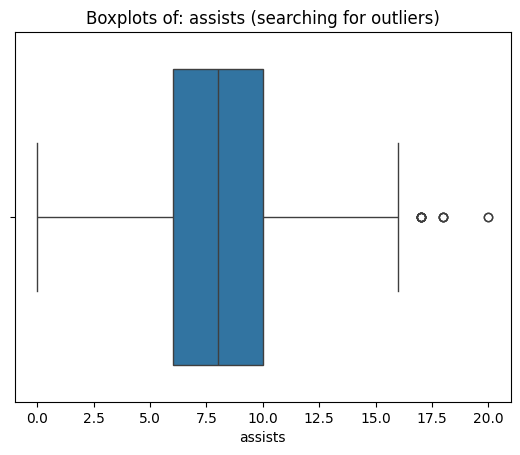





--------------------------------------------------------------------
Feature: deaths


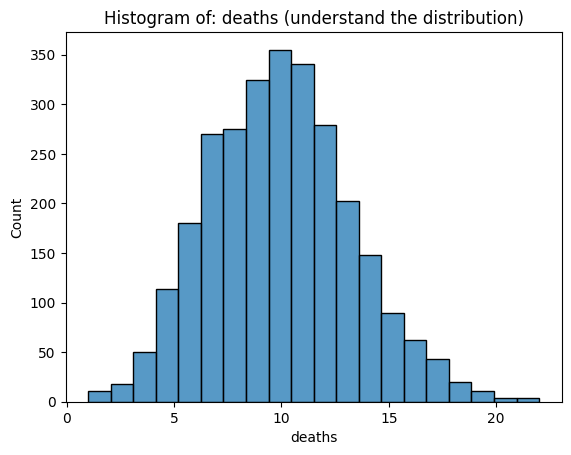

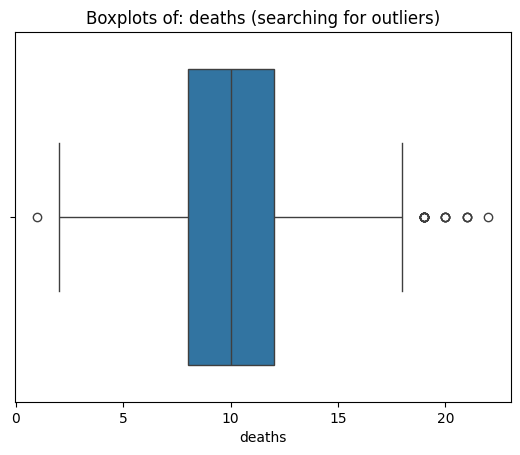





--------------------------------------------------------------------
Feature: accuracy_percent


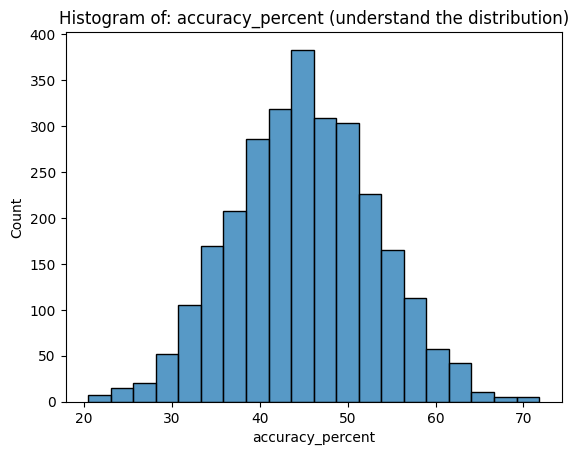

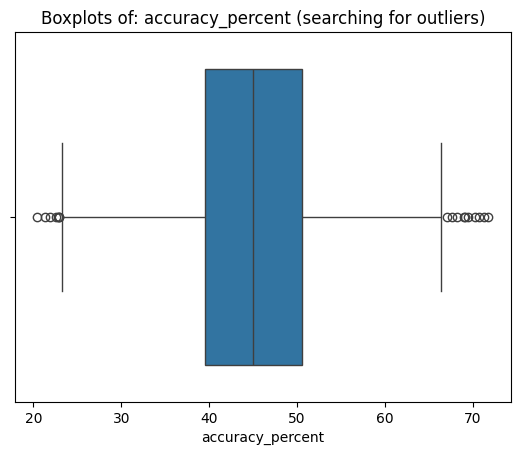





--------------------------------------------------------------------
Feature: reaction_time_ms


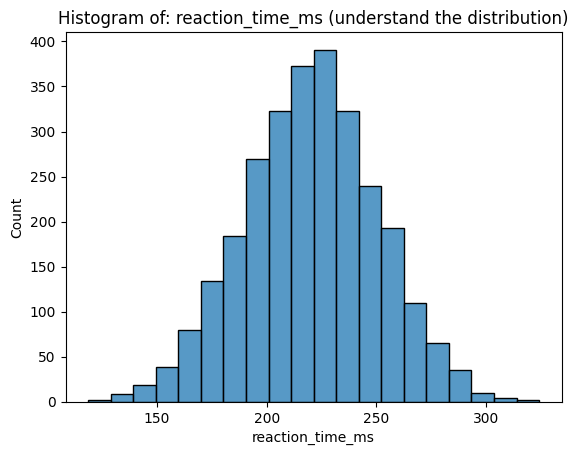

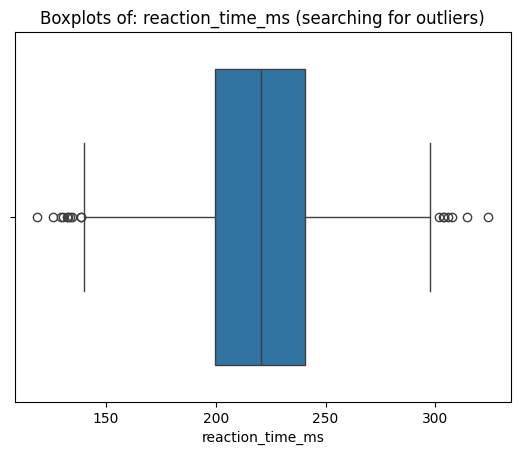





--------------------------------------------------------------------
Feature: fatigue_index


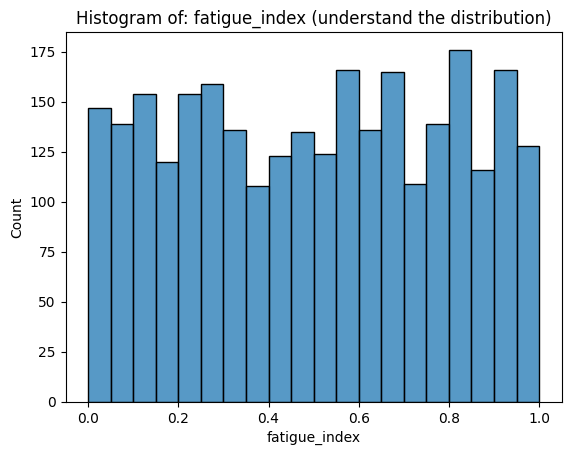

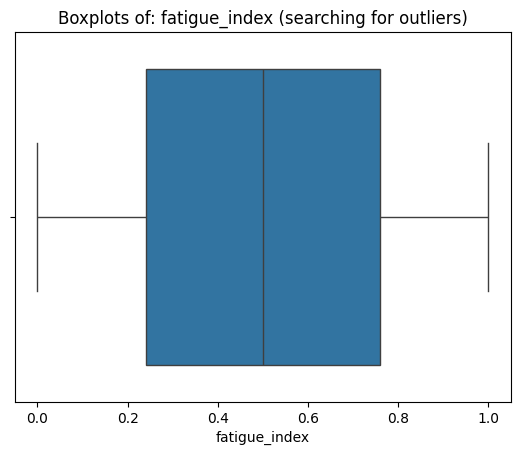





--------------------------------------------------------------------
Feature: performance_score


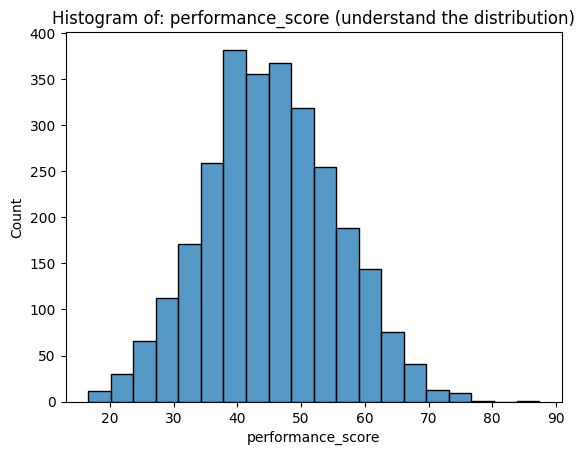

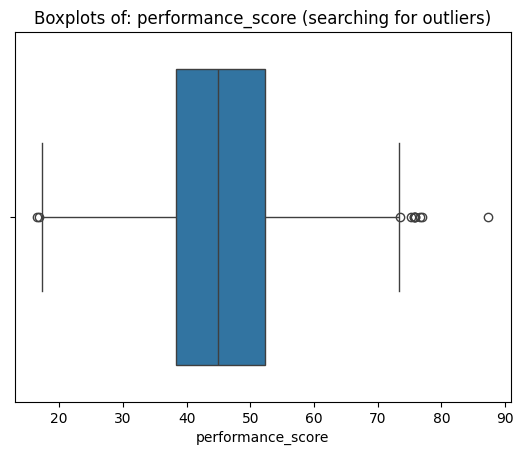





--------------------------------------------------------------------
Feature: win_probability


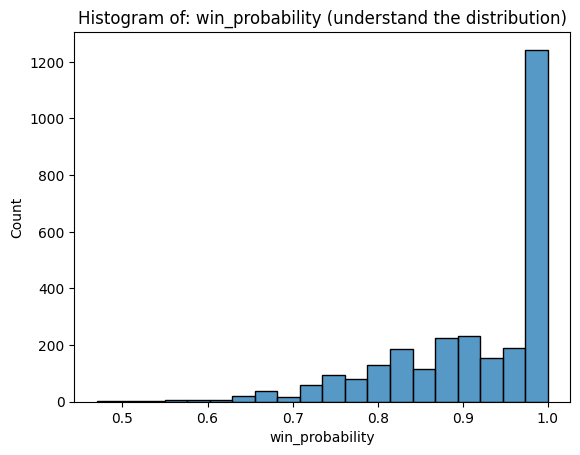

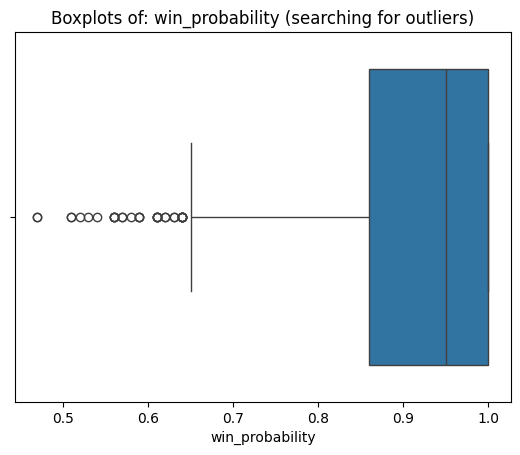

In [89]:
for nf in numeric_features:
    print(f'--------------------------------------------------------------------')
    print(f'Feature: {nf}')

    # Histogram
    sns.histplot(data = df, x = nf, bins = 20)
    plt.title(f'Histogram of: {nf} (understand the distribution)')
    plt.show()
    
    # BoxPlots
    sns.boxplot(data = df, x = nf)
    plt.title(F'Boxplots of: {nf} (searching for outliers)')
    plt.show()
    
    print(f'\n\n\n')

--------------------------------------------------------------------
Feature: team_name


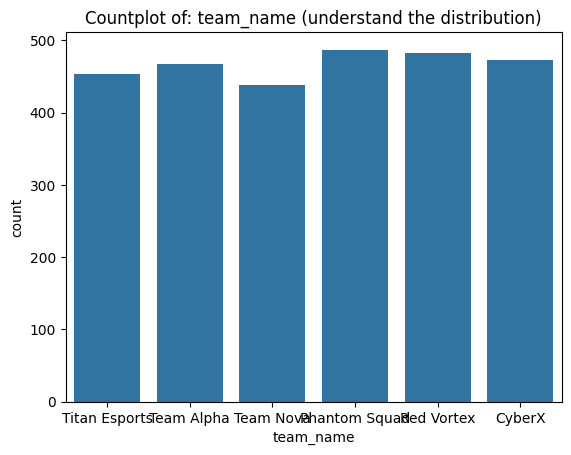

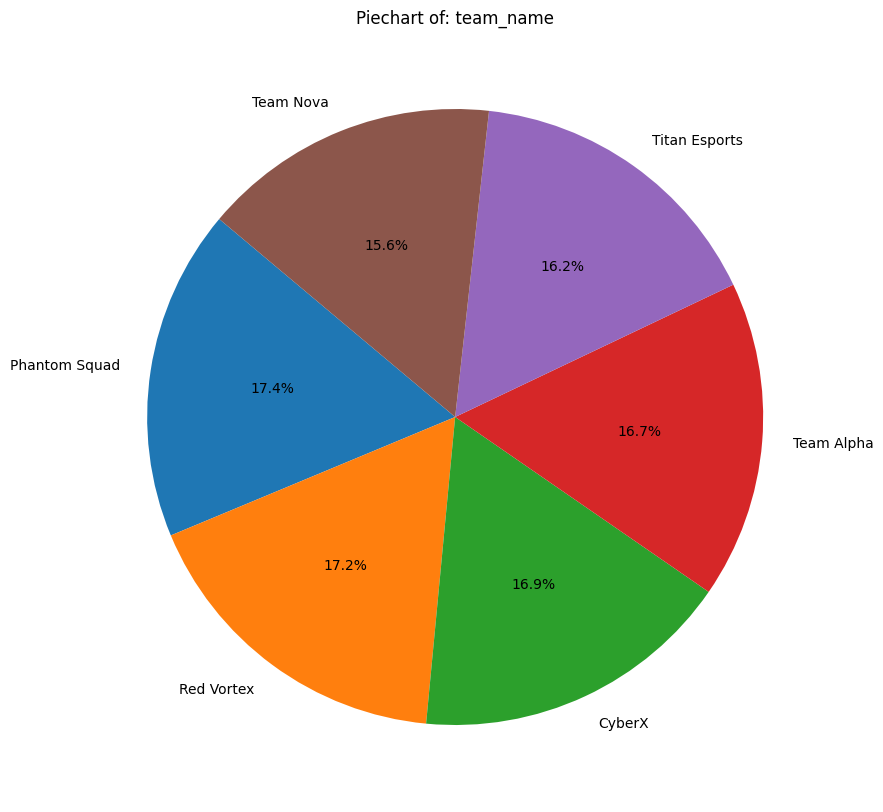





--------------------------------------------------------------------
Feature: player_role


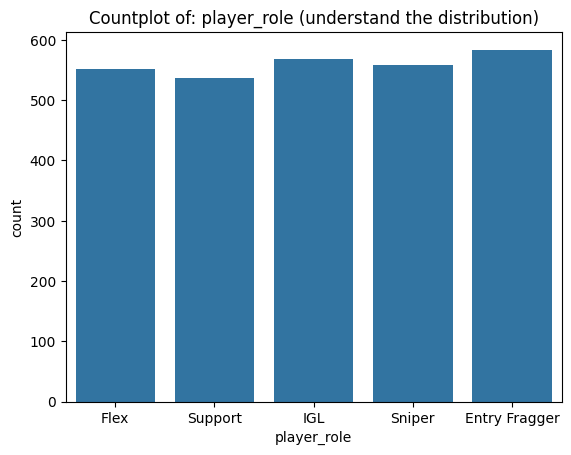

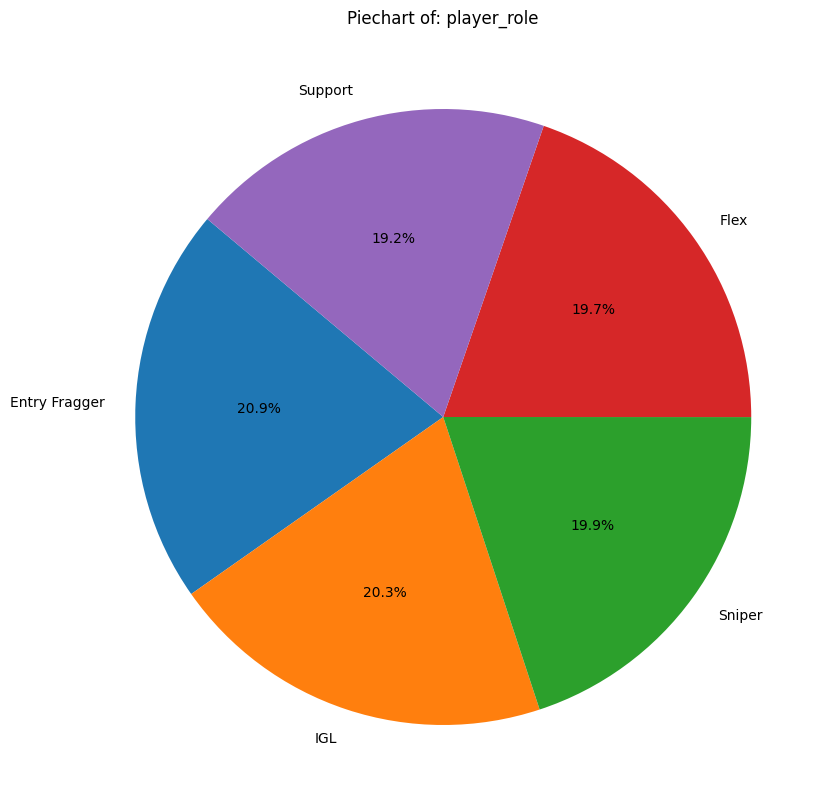





--------------------------------------------------------------------
Feature: map_played


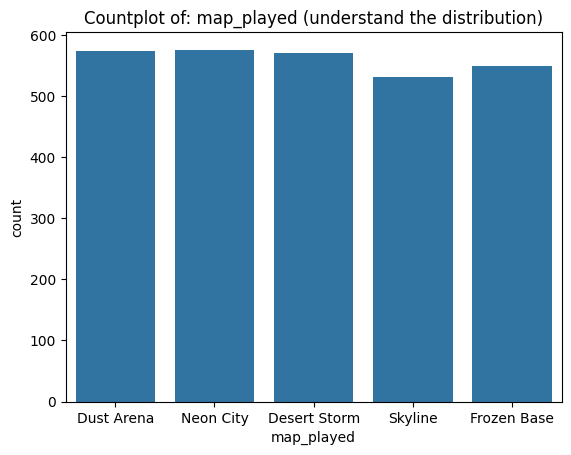

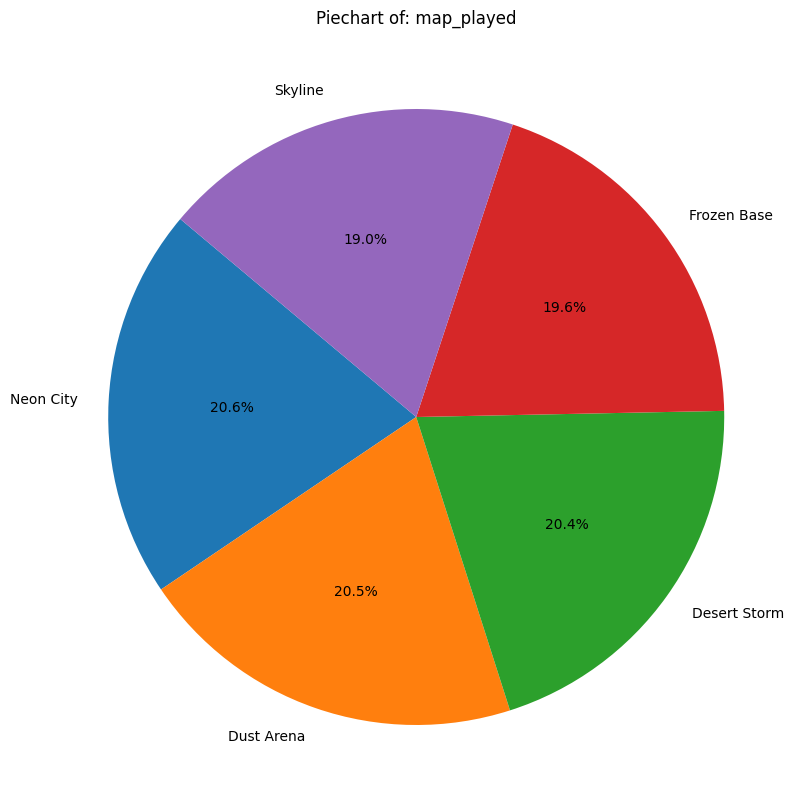





--------------------------------------------------------------------
Feature: match_type


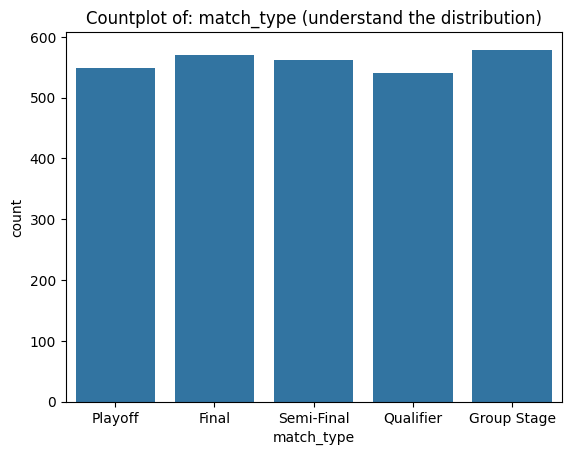

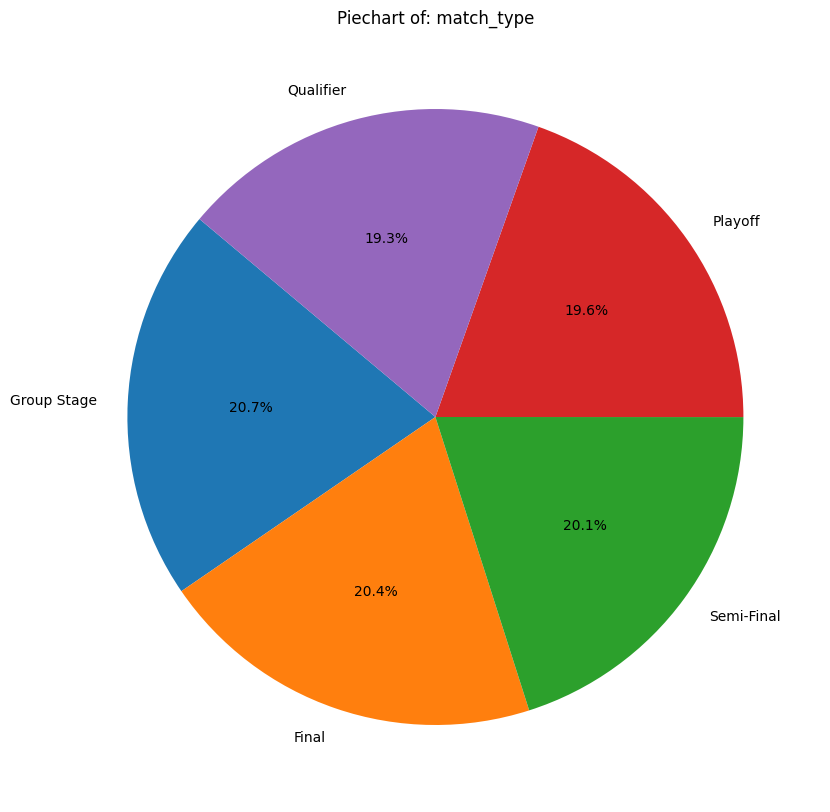





--------------------------------------------------------------------
Feature: match_outcome


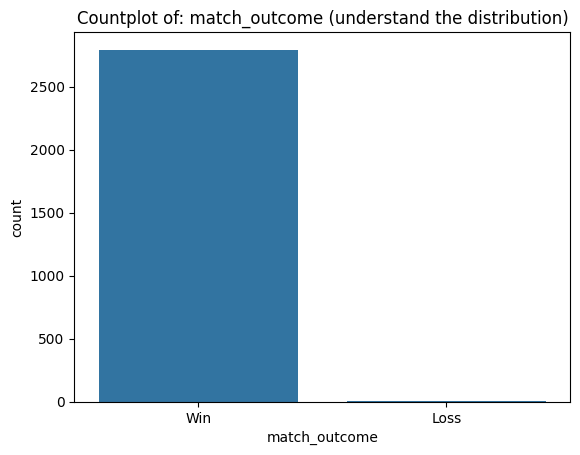

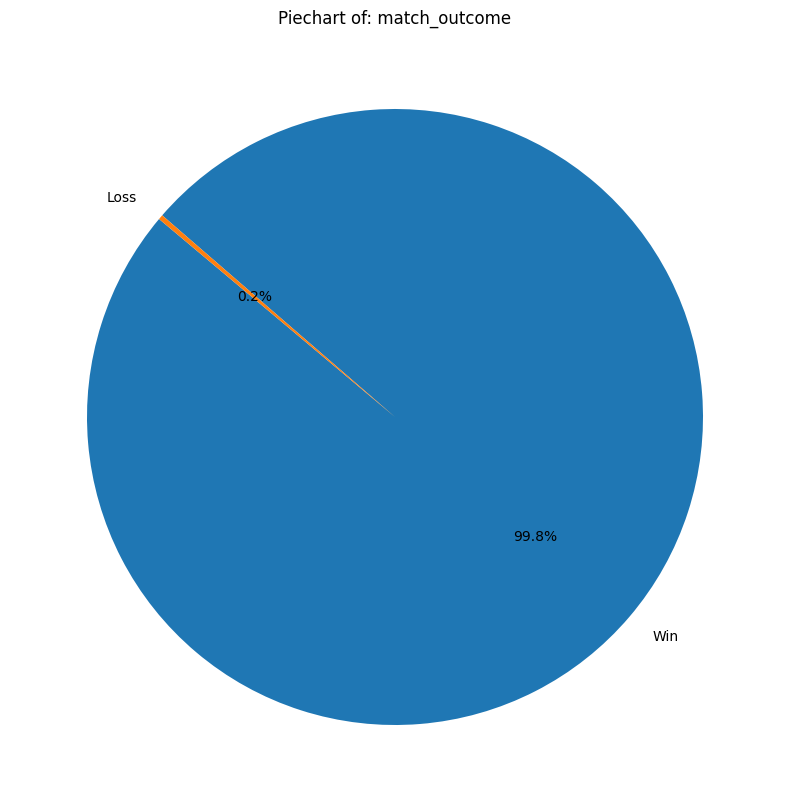





--------------------------------------------------------------------
Feature: mvp_award


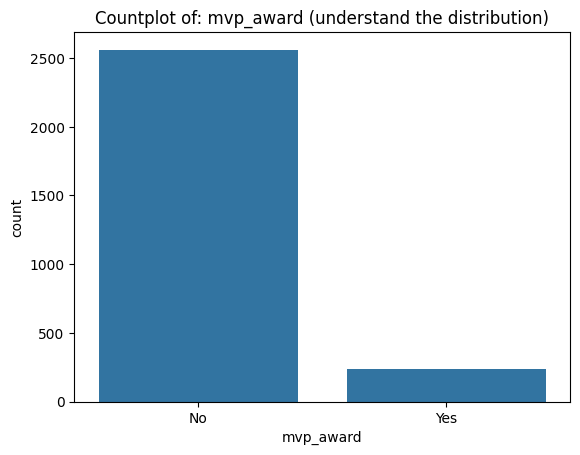

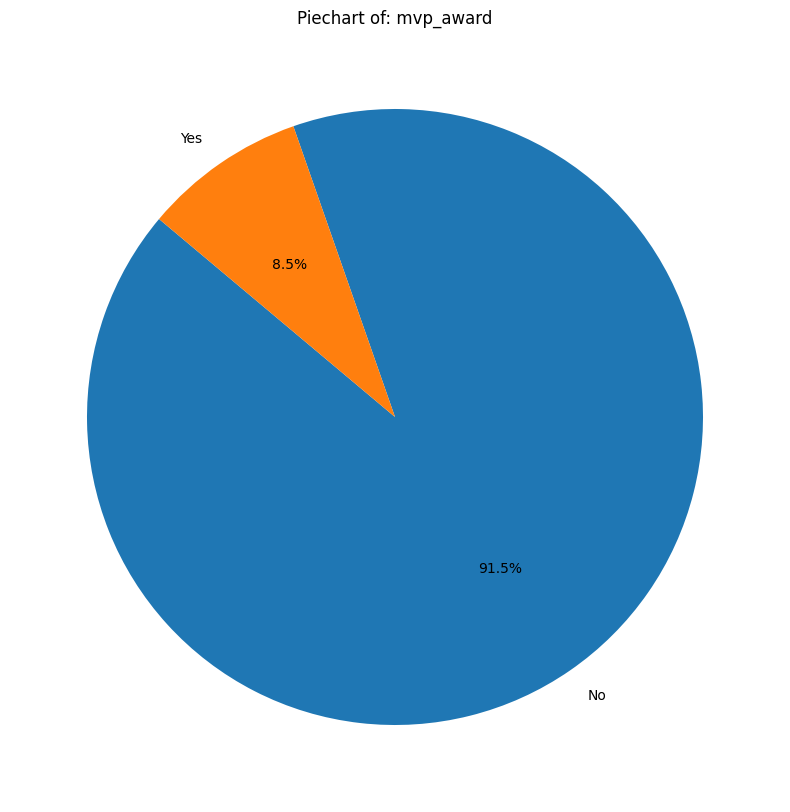

In [90]:
for cf in categorial_features:
    print(f'--------------------------------------------------------------------')
    print(f'Feature: {cf}')

    # Countplot
    sns.countplot(data = df, x = cf)
    plt.title(f'Countplot of: {cf} (understand the distribution)')
    plt.show()
    
    # Piechart (pizzas)
    counts = df[cf].value_counts()
    plt.figure(figsize=(10,10))
    plt.pie(counts, labels = counts.index,  autopct='%1.1f%%', startangle=140)
    plt.title(F'Piechart of: {cf}')
    plt.show()
    
    print(f'\n\n\n')

### Correlation (Feature x TARGET)

In [91]:
# Get the numeric and categorial features again but now without the target
features = df.drop('match_outcome', axis = 1) 
numeric_features = features.select_dtypes(include='number').columns.tolist()
categorial_features = features.select_dtypes(exclude='number').columns.tolist()

target = 'match_outcome'



Feature: record_id


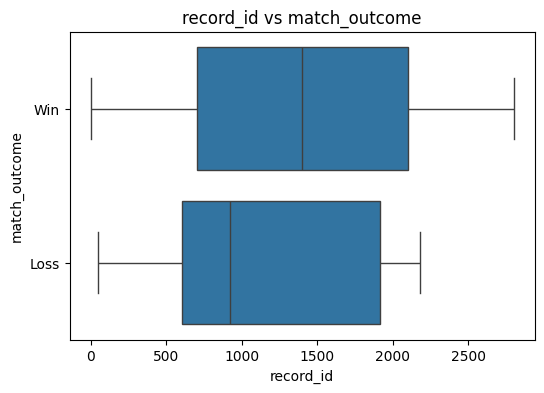





Feature: player_id


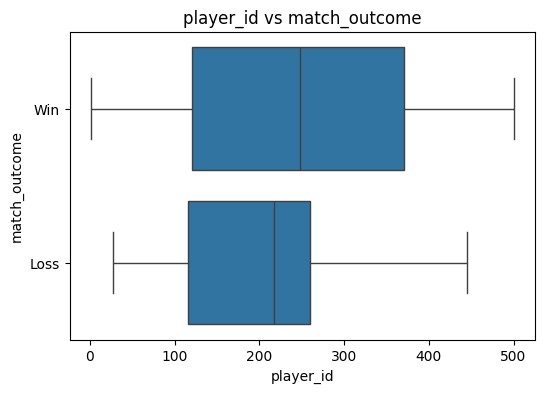





Feature: kills


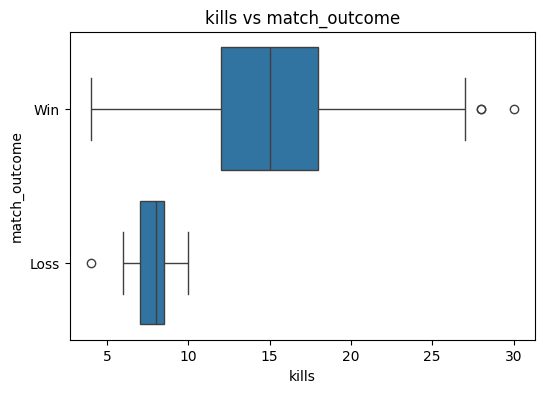





Feature: assists


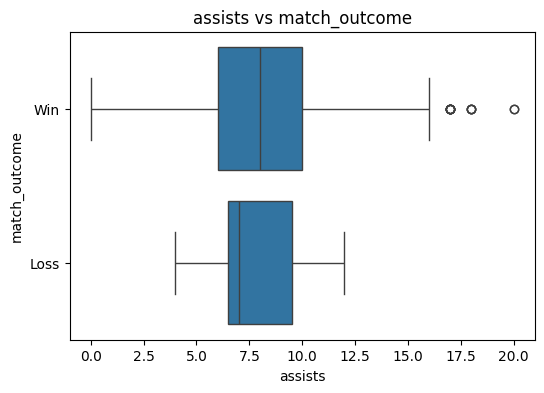





Feature: deaths


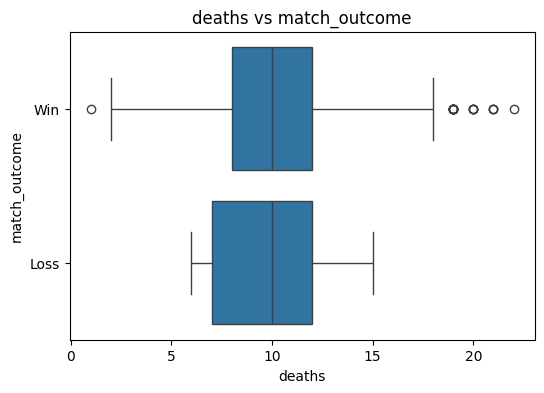





Feature: accuracy_percent


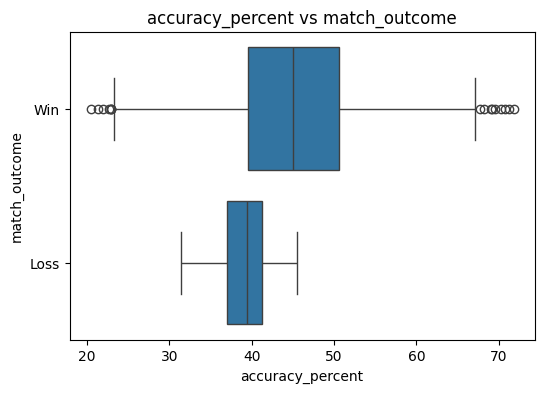





Feature: reaction_time_ms


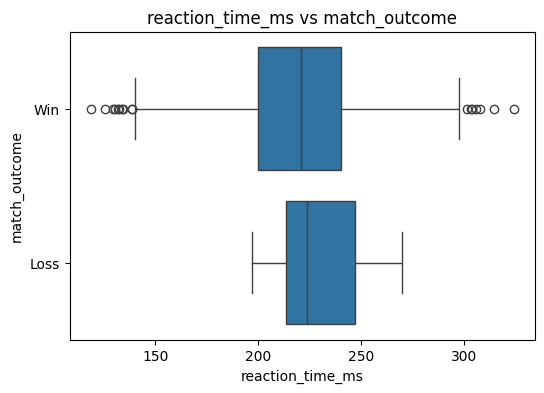





Feature: fatigue_index


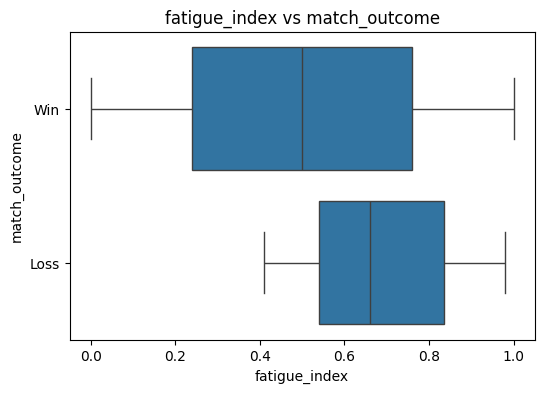





Feature: performance_score


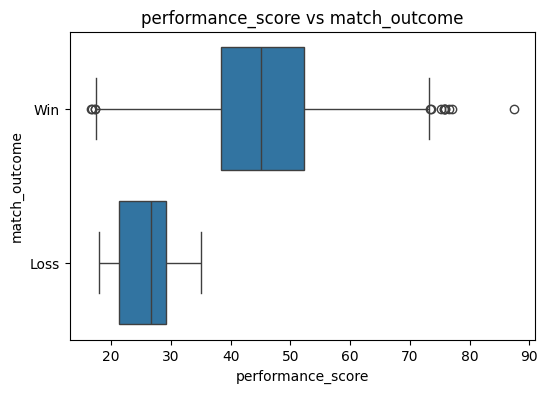





Feature: win_probability


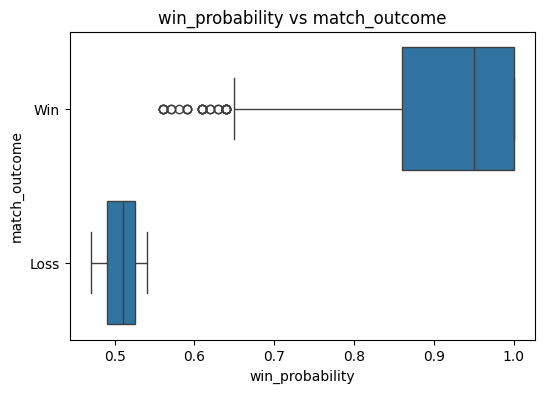

In [92]:
# Numeric X TARGET

for feature in numeric_features: 
    print(f'==================================================')
    print(f'Feature: {feature}')

    plt.figure(figsize=(6,4))
    sns.boxplot(data = df, x=feature, y=target)
    plt.title(f'{feature} vs match_outcome')
    plt.show()

    print(f'\n\n\n')



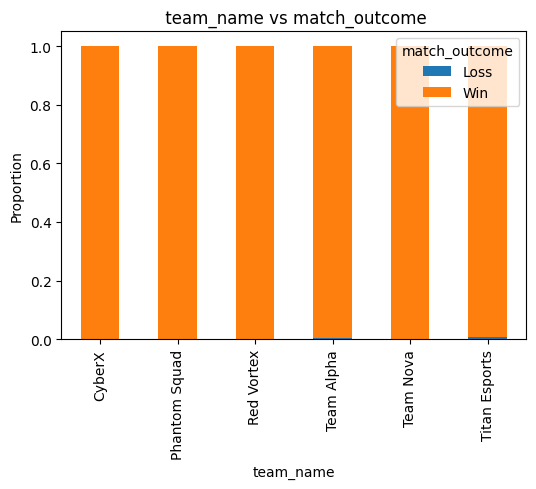

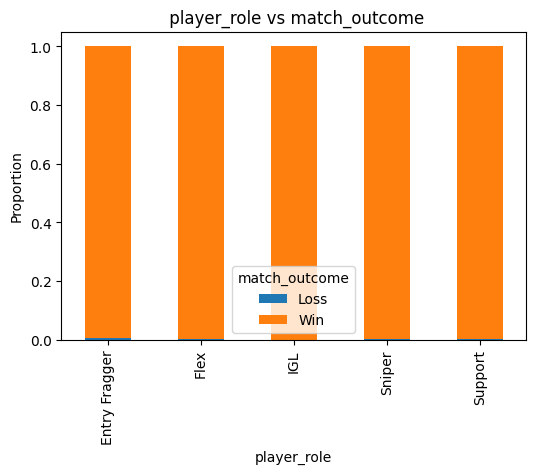

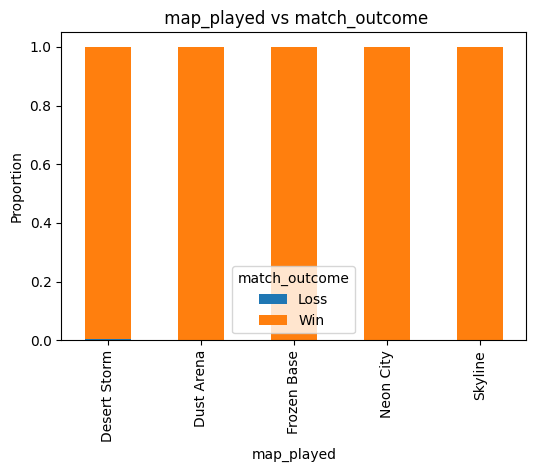

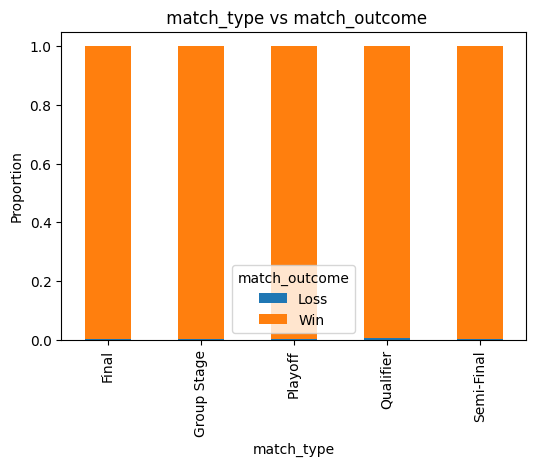

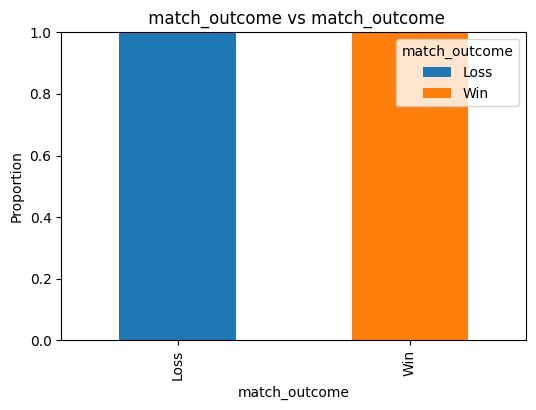

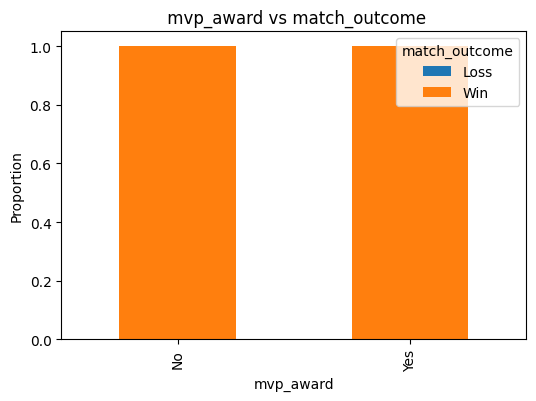

In [97]:
# String X TARGET

for feature in categorial_features:
    ct = pd.crosstab(df[feature], df[target], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f' {feature} vs match_outcome')
    plt.ylabel('Proportion')
    plt.show()


### Multicolinearity

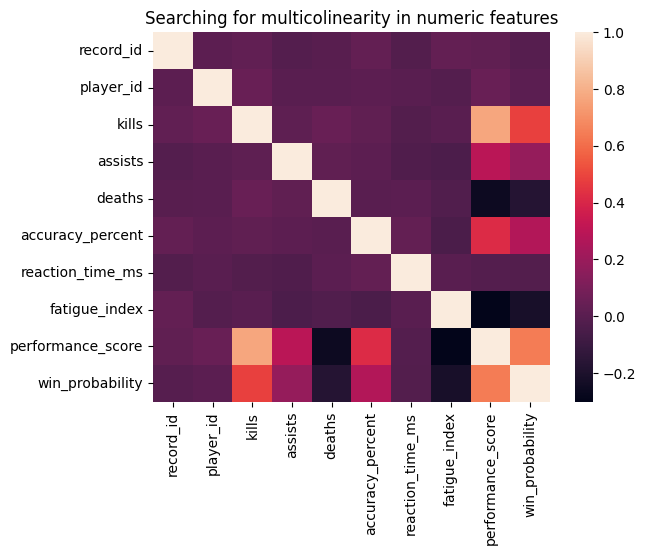

In [101]:
corr = (df.select_dtypes(include='number')).corr()
sns.heatmap(corr)
plt.title("Searching for multicolinearity in numeric features")
plt.show()

In [104]:
for feature in numeric_features:
    corr = df[numeric_features].corr()[feature].sort_values(ascending= False)
    print(f'\nCorrelation of: {feature}')
    print(corr)


Correlation of: record_id
record_id            1.000000
fatigue_index        0.033800
accuracy_percent     0.029408
kills                0.027062
performance_score    0.020878
player_id            0.008610
deaths              -0.006083
win_probability     -0.008539
assists             -0.013542
reaction_time_ms    -0.017145
Name: record_id, dtype: float64

Correlation of: player_id
player_id            1.000000
kills                0.049226
performance_score    0.046736
accuracy_percent     0.012175
record_id            0.008610
win_probability      0.006864
reaction_time_ms     0.003150
assists             -0.000087
deaths              -0.001422
fatigue_index       -0.013200
Name: player_id, dtype: float64

Correlation of: kills
kills                1.000000
performance_score    0.767174
win_probability      0.481693
player_id            0.049226
deaths               0.046680
record_id            0.027062
accuracy_percent     0.020081
assists              0.018341
fatigue_index      

# EDA for Data Preprocessing

In [106]:
categorial_features = df.select_dtypes(exclude='number')
categorial_features.head()


,team_name,player_role,map_played,match_type,match_outcome,mvp_award
0,Titan Esports,Flex,Dust Arena,Playoff,Win,No
1,Titan Esports,Support,Neon City,Final,Win,No
2,Team Alpha,Support,Neon City,Semi-Final,Win,No
3,Team Nova,IGL,Desert Storm,Final,Win,No
4,Phantom Squad,Sniper,Skyline,Playoff,Win,No


In [107]:
for x in categorial_features.columns:
# Cardinality of Categorial features
    print(f"Cardinality of {x}: {df[x].nunique()}")

Cardinality of team_name: 6
Cardinality of player_role: 5
Cardinality of map_played: 5
Cardinality of match_type: 5
Cardinality of match_outcome: 2
Cardinality of mvp_award: 2


# Exploratory Data Analysis (EDA) Report

**Project:** Player Performance Modeling & Match Prediction  
**Status:** Completed - Pre-processing Phase  

---

## 1. Dataset Overview
The dataset contains performance metrics from competitive matches, focusing on combat and behavioral data.

* **Dimensions:** 2,800 samples with 16 features.
* **Data Integrity:** 0 null or missing values detected.
* **Initial Cleaning:** `record_id` and `player_id` were removed as they are unique identifiers with no predictive power.


## 2. Data Quality & Distributions
A statistical analysis of the "shape" and behavior of numerical and categorical variables.

### Numerical Features
* **Kills, Assists, Deaths, and Performance_Score:** Display unimodal (pyramid-shaped) distributions with low outlier incidence.
* **Accuracy_Percent and Reaction_Time_MS:** Centered distributions with a moderate amount of outliers, suggesting the need for robust scaling.
* **Fatigue_Index:** Well-balanced (Gaussian) distribution with no significant outliers.
* **WinProbability:** Identified as highly skewed. 
    * *Action:* **Log Transformation** will be applied to normalize the variance.

### Categorical Variables & Targets
* **Balanced Features:** `Team_Name`, `player_role`, `map_played`, and `match_type`.
* **Imbalanced Targets:** `match_outcome` and `mvp_award` (Binary Classes) show severe class imbalance.
    * *Strategy:* Implementation of `class_weights` or oversampling techniques (e.g., SMOTE) during training.

## 3. Correlation & Multicollinearity Analysis
The correlation matrix revealed key dependencies that guide feature selection.

| Feature A | Feature B | Correlation Level | Insight |
| :--- | :--- | :--- | :--- |
| **Kills** | **Performance_Score** | High | Potential redundancy/multicollinearity. |
| **Performance_Score** | **WinProbability** | High | Strong performance indicator. |
| **Accuracy_Percent** | **Performance_Score** | Medium | Moderate contribution to the final score. |
| **Assists / Deaths** | **Performance_Score** | Low | Lower individual impact than expected. |
| **Reaction_Time** | *(Any)* | None | Independent variable in the dataset. |

> **Critical Note on Data Leakage:** The `WinProbability` feature was removed from the training set. Since it effectively defines the target, keeping it would lead to an overfitted model that is unusable in real-time scenarios.

## 4. Feature vs. Target Relationship
* **Determining Factors:** `Kills`, `Fatigue_Index`, and `Performance_Score` show clear statistical separation in boxplots between winners and losers.
* **Neutral Factors:** `Assists`, `Accuracy_Percent`, and `Reaction_Time` have overlapping medians, indicating low individual predictive power for match outcomes.


## 5. EDA for Pre-processing (Feature Engineering)
Converting insights into mathematical transformations:

* **Binary Encoding (Targets):** `match_outcome` and `mvp_award` converted to $0$ and $1$ via `LabelEncoder`.
* **One-Hot Encoding (Features):** Applied to `player_role` and `map_played`, and the others we can drop.


## 6. Model Tuning & Optimization Strategy
Addressing class imbalance and hyperparameter efficiency:

### Handling Imbalance
* **Metrics:** Shift focus from *Accuracy* to **Precision-Recall AUC** and **F1-Score**.
* **Algorithms:** Prioritizing Tree-based models (**XGBoost**, **LightGBM**) for their native `scale_pos_weight` parameter.

### Hyperparameter Search Space
1.  **RandomizedSearchCV:** Broad search to identify high-performance regions for `learning_rate`, `max_depth`, and `n_estimators`.
2.  **GridSearchCV:** Fine-tuning the best candidates.
3.  **Regularization:** Tuning Alpha ($L1$) and Lambda ($L2$) to handle low-correlation features that were retained.